# Optimization Methods

Pablo Winant

In this tutorial you will learn to code and use common optimization
algorithms for static models.

------------------------------------------------------------------------

## Profit optimization by a monopolist

A monopolist produces quantity $q$ of goods X at price $p$. Its cost
function is $c(q) = 0.5 + q (1-qe^{-q})$

The consumer’s demand for price $p$ is $x(p)=2 e^{-0.5 p}$ (constant
elasticity of demand to price).

1.  **Write down the profit function of the monopolist and find the
    optimal production (if any). Don’t use any library except for
    plotting.**

In [1]:
using Plots

In [2]:
c(q) = 0.5 + q*(1-q*exp(-q))
x(p) = 2*exp(-0.5p)
π(p) = p*x(p) - c(x(p))

π (generic function with 1 method)

In [8]:
pvec = 0.1:0.01:4.0
# πvec = [π(e) for e in pvec] # vector comprhension: as in python but yields a vector
πvec = π.(pvec);   # vectorized call

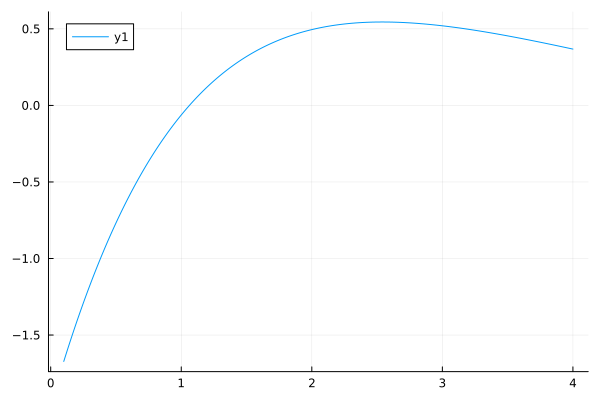

In [9]:
plot(pvec, πvec)

In [ ]:
# grid search
pvec = range(;start=0.1, stop=4.0, length=1000000)


# this version allocates πvec
# πvec = π.(pvec);   # vectorized call
# i_max = argmax(πvec)

# This one doesn't
i_max = argmax(map(π, pvec))
p_max = pvec[i_max]

2.5393003393003393

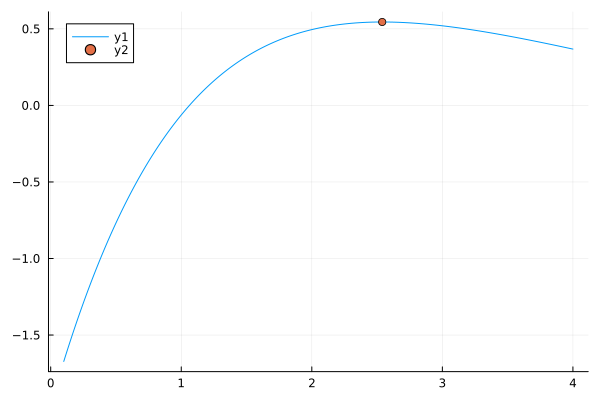

In [15]:
plot(pvec, πvec)
scatter!([p_max], [π(p_max)])

In [34]:
# derivatives of π


using ForwardDiff
π1(p) = ForwardDiff.derivative(π,p)
π2(p) = ForwardDiff.derivative(π1,p)

π2 (generic function with 1 method)

In [36]:
π2(0.4)

-2.079405263105777

In [45]:
# p0 = 2.0
function solve_profit(π, p0; tol_η = 1e-10)

    π1(p) = ForwardDiff.derivative(π,p)
    π2(p) = ForwardDiff.derivative(π1,p)

    for t = 1:100
        p1 = p0 - π1(p0)/π2(p0)
        η = abs(p1 - p0)
        println(t, η)
        if η < tol_η
            return p1
        end
        p0 = p1
    end

end


solve_profit (generic function with 2 methods)

In [46]:
solve_profit(π, 2.0)

10.41122344380439246
20.11939558775904713
30.008640374066304357
44.2346230528345075e-5
51.0117813253884833e-9
60.0


2.5393017528720536

------------------------------------------------------------------------

## Constrained optimization

Consider the function $f(x,y) = 1-(x-0.5)^2 -(y-0.3)^2$.

1.  **Use Optim.jl to maximize $f$ without constraint. Check you
    understand diagnostic information returned by the optimizer.**

In [3]:
# your code here

1.  **Now, consider the constraint $x<0.3$ and maximize $f$ under this
    new constraint.**

In [4]:
# your code here

1.  **Reformulate the problem as a root finding problem with
    lagrangians. Write the complementarity conditions.**

In [5]:
# your code here

1.  **Solve using NLSolve.jl**

In [6]:
# your code here

------------------------------------------------------------------------

## Consumption optimization

A consumer has preferences $U(c_1, c_2)$ over two consumption goods
$c_1$ and $c_2$.

Given a budget $I$, consumer wants to maximize utility subject to the
budget constraint $p_1 c_1 + p_2 c_2 \leq I$.

We choose a Stone-Geary specification where

$U(c_1, c_2)=\beta_1 \log(c_1-\gamma_1) + \beta_2 \log(c_2-\gamma_2)$

1.  **Write the Karush-Kuhn-Tucker necessary conditions for the
    problem.**

In [7]:
# your code here

1.  **Verify the KKT conditions are sufficient for optimality.**

In [8]:
# your code here

1.  **Derive analytically the demand functions, and the shadow price.**

In [9]:
# your code here

1.  **Interpret this problem as a complementarity problem and solve it
    using NLSolve.**

In [10]:
# your code here

1.  **Produce some nice graphs with isoutility curves, the budget
    constraint and the optimal choice.**

In [11]:
# your code here